# Task2:ExploratoryDataAnalysis(EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# TASK 1 — Summary Statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [9]:
df.median(numeric_only=True)

,0
PassengerId,446.0000
Survived,0.0000
Pclass,3.0000
Age,28.0000
SibSp,0.0000
Parch,0.0000
Fare,14.4542


In [10]:
df.mode().iloc[0]


,0
PassengerId,1
Survived,0.0
Pclass,3.0
Name,"Abbing, Mr. Anthony"
Sex,male
Age,24.0
SibSp,0.0
Parch,0.0
Ticket,1601
Fare,8.05


In [11]:
df.skew(numeric_only=True)

,0
PassengerId,0.000000
Survived,0.478523
Pclass,-0.630548
Age,0.389108
SibSp,3.695352
Parch,2.749117
Fare,4.787317


In [13]:
# TASK 2 — Histograms & Boxplots
num_cols = ["Age", "Fare", "SibSp", "Parch"]

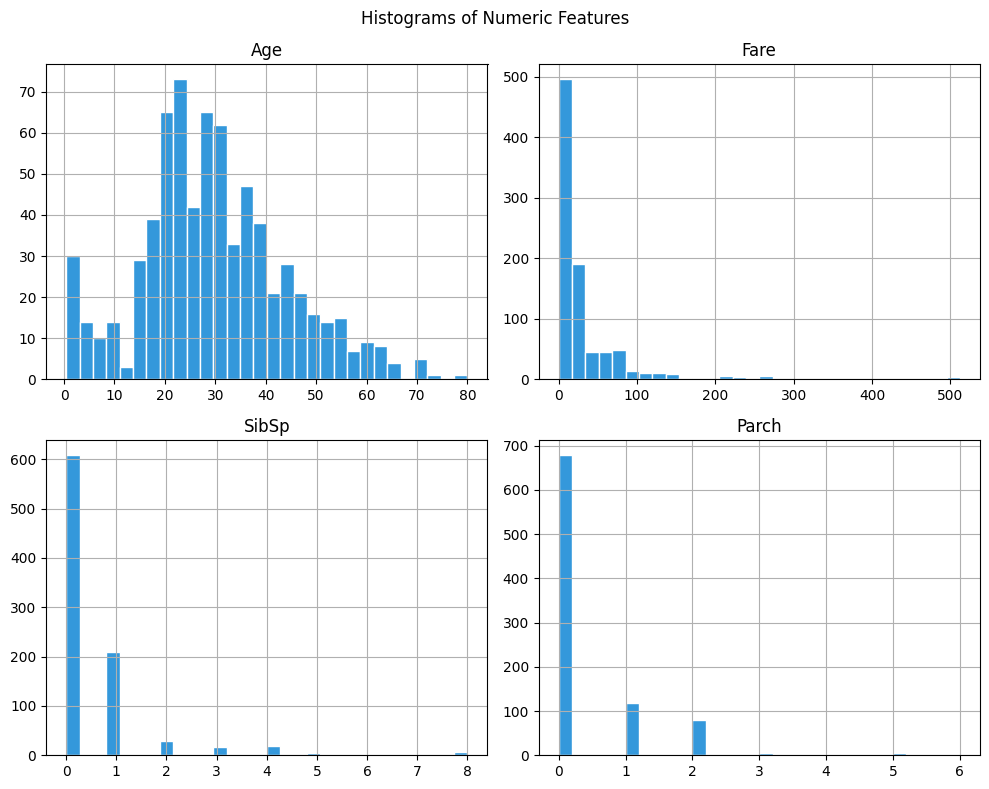

In [14]:
# Histograms
df[num_cols].hist(figsize=(10, 8), bins=30, color="#3498DB", edgecolor="white")
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

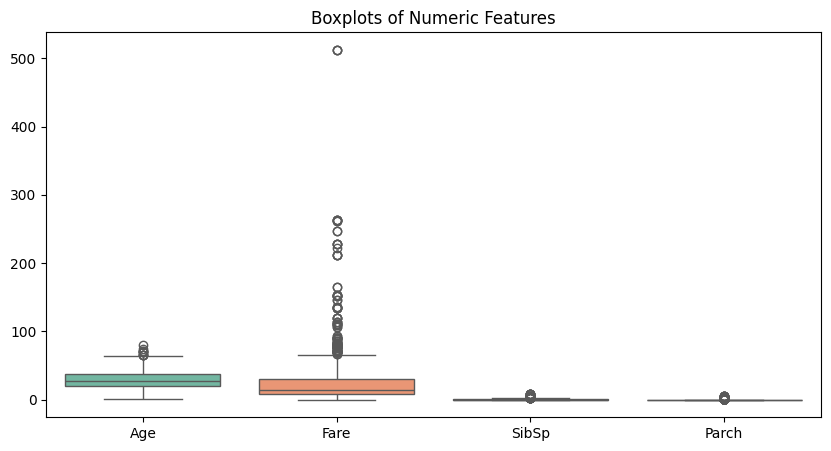

In [15]:
# Boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[num_cols], palette="Set2")
plt.title("Boxplots of Numeric Features")
plt.show()

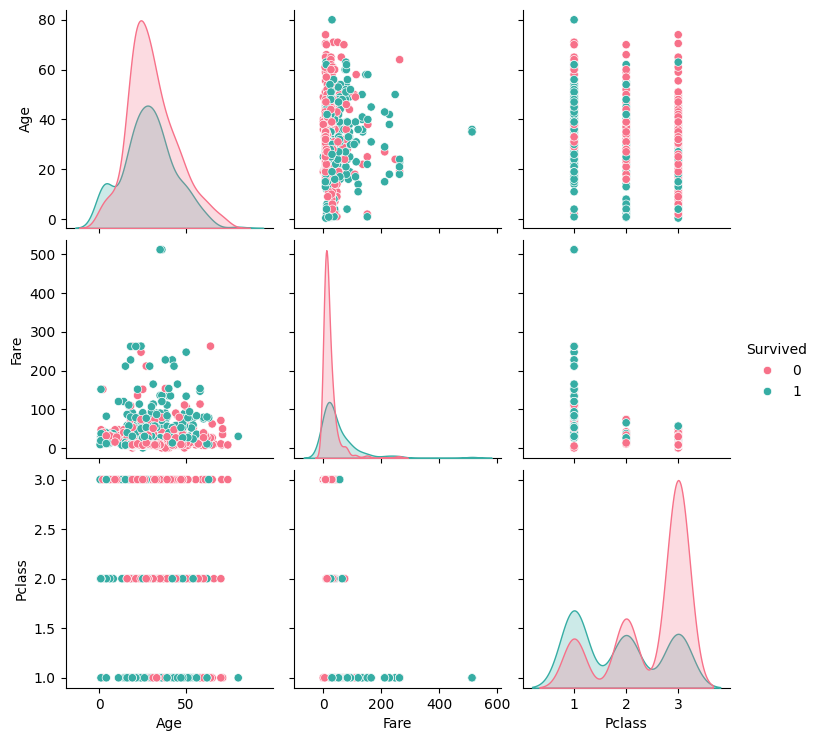

In [16]:
# TASK 3 — Pairplot & Correlation Matrix

# Pairplot (relationships between features, colored by survival)
sns.pairplot(df[["Survived", "Age", "Fare", "Pclass"]].dropna(), hue="Survived", palette="husl")
plt.show()


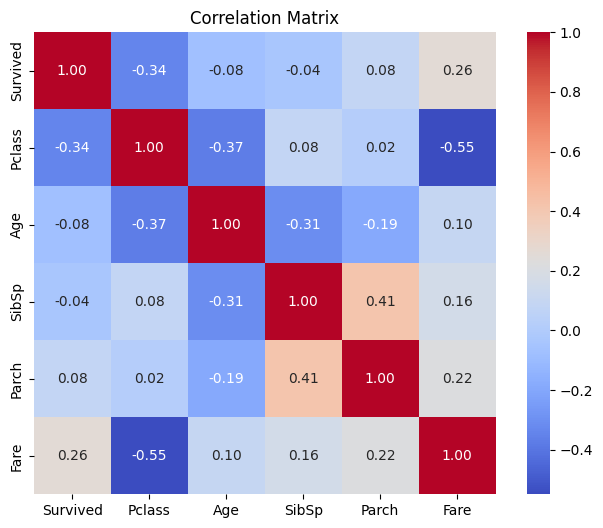

In [17]:
# Correlation matrix
plt.figure(figsize=(8, 6))
corr = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

In [18]:
# Interactive correlation heatmap (Plotly)
fig = px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", title="Correlation Matrix (Interactive)")
fig.show()

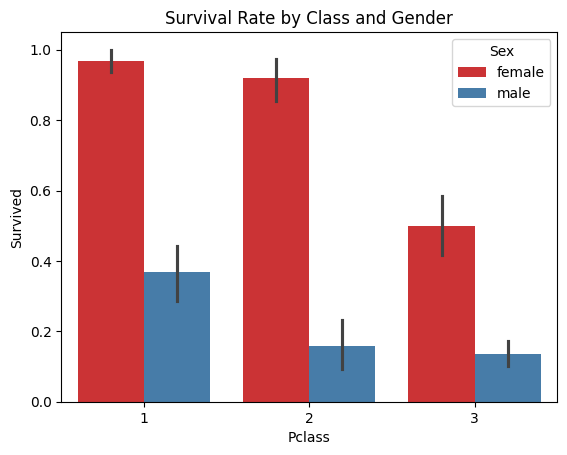

In [19]:
# TASK 4 — Patterns, Trends & Anomalies

# Survival rate by gender and class
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", palette="Set1")
plt.title("Survival Rate by Class and Gender")
plt.show()

In [20]:
# Fare vs Age, colored by survival (interactive)
fig = px.scatter(df, x="Age", y="Fare", color="Survived", title="Fare vs Age by Survival")
fig.show()


In [21]:

# Outlier check (Fare has known extreme values)
print("Top 5 highest fares:")
print(df.nlargest(5, "Fare")[["Name", "Fare", "Pclass"]])


Top 5 highest fares:
                                   Name      Fare  Pclass
258                    Ward, Miss. Anna  512.3292       1
679  Cardeza, Mr. Thomas Drake Martinez  512.3292       1
737              Lesurer, Mr. Gustave J  512.3292       1
27       Fortune, Mr. Charles Alexander  263.0000       1
88           Fortune, Miss. Mabel Helen  263.0000       1


In [23]:
# TASK 5 — Feature-Level

print("\n--- Basic Inferences ---")
print("Overall survival rate:", round(df["Survived"].mean(), 2))
print("Survival rate by gender:\n", df.groupby("Sex")["Survived"].mean())
print("Survival rate by class:\n", df.groupby("Pclass")["Survived"].mean())
print("Average age of survivors vs non-survivors:\n", df.groupby("Survived")["Age"].mean())
print("Average fare paid by class:\n", df.groupby("Pclass")["Fare"].mean())


--- Basic Inferences ---
Overall survival rate: 0.38
Survival rate by gender:
 Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Survival rate by class:
 Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Average age of survivors vs non-survivors:
 Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64
Average fare paid by class:
 Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
